## About Dataset
Context
This is a small subset of dataset of Book reviews from Amazon Kindle Store category.

Content
5-core dataset of product reviews from Amazon Kindle Store category from May 1996 - July 2014. Contains total of 982619 entries. Each reviewer has at least 5 reviews and each product has at least 5 reviews in this dataset.
Columns

- asin - ID of the product, like B000FA64PK
- helpful - helpfulness rating of the review - example: 2/3.
- overall - rating of the product.
- reviewText - text of the review (heading).
- reviewTime - time of the review (raw).
- reviewerID - ID of the reviewer, like A3SPTOKDG7WBLN
- reviewerName - name of the reviewer.
- summary - summary of the review (description).
- unixReviewTime - unix timestamp.

Acknowledgements
This dataset is taken from Amazon product data, Julian McAuley, UCSD website. http://jmcauley.ucsd.edu/data/amazon/

License to the data files belong to them.

Inspiration
- Sentiment analysis on reviews.
- Understanding how people rate usefulness of a review/ What factors influence helpfulness of a review.
- Fake reviews/ outliers.
- Best rated product IDs, or similarity between products based on reviews alone (not the best idea ikr).
- Any other interesting analysis

#### Best Practises
1. Preprocessing And Cleaning
2. Train Test Split
3. BOW,TFIDF,Word2vec
4. Train ML algorithms

In [39]:
import pandas as pd

data = pd.read_csv("../data/raw/all_kindle_review.csv")
data.head()


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [60]:
df = data[['reviewText', 'rating']].copy()
df.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


In [41]:
df.shape

(12000, 2)

In [42]:
df.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [43]:
df['rating'].unique()

array([3, 5, 4, 2, 1])

In [44]:
df['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

## Preprocessing And Cleaning

In [92]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


In [93]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\simi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\simi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\simi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [94]:
data = pd.read_csv("../data/raw/all_kindle_review.csv")
data = data[['reviewText', 'rating']].dropna().copy()

data.head()


,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


In [95]:
# Positive = rating > 3, Negative = rating <= 3
data['sentiment'] = (data['rating'] > 3).astype(int)

data['sentiment'].value_counts()


sentiment
0    6000
1    6000
Name: count, dtype: int64

In [96]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)              # remove punctuation & numbers
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    return " ".join(text)


In [97]:
data['clean_text'] = data['reviewText'].apply(preprocess_text)

data[['reviewText', 'clean_text']].head()


,reviewText,clean_text
0,"Jace Rankin may be short, but he's nothing to ...",jace rankin may short he nothing mess man haul...
1,Great short read. I didn't want to put it dow...,great short read didnt want put read one sitti...
2,I'll start by saying this is the first of four...,ill start saying first four book wasnt expecti...
3,Aggie is Angela Lansbury who carries pocketboo...,aggie angela lansbury carry pocketbook instead...
4,I did not expect this type of book to be in li...,expect type book library pleased find price right


In [98]:
X = data['clean_text']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [99]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [100]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [101]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8420833333333333
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1200
           1       0.85      0.83      0.84      1200

    accuracy                           0.84      2400
   macro avg       0.84      0.84      0.84      2400
weighted avg       0.84      0.84      0.84      2400



EDA

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [103]:
data['sentiment'].value_counts()


sentiment
0    6000
1    6000
Name: count, dtype: int64

In [104]:
data['sentiment'].value_counts(normalize=True)


sentiment
0    0.5
1    0.5
Name: proportion, dtype: float64

<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

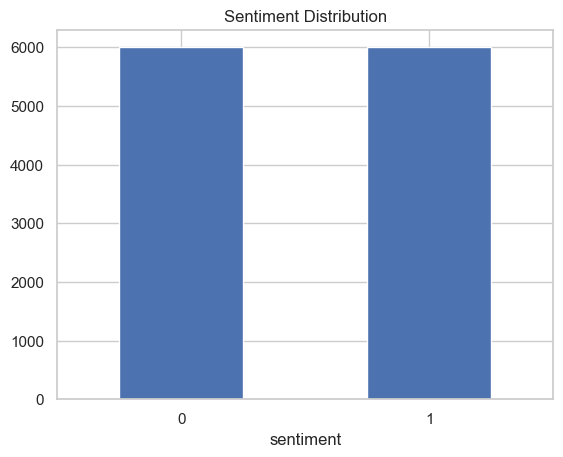

In [110]:
data['sentiment'].value_counts().plot(
    kind='bar',
    title='Sentiment Distribution',
    rot=0
)


In [111]:
pd.crosstab(data['rating'], data['sentiment'])


sentiment,0,1
rating,,
1,2000,0
2,2000,0
3,2000,0
4,0,3000
5,0,3000


In [112]:
data['text_len'] = data['clean_text'].str.split().apply(len)
data['text_len'].describe()


count    12000.000000
mean        54.175417
std         63.492230
min          1.000000
25%         16.000000
50%         30.000000
75%         66.000000
max       1126.000000
Name: text_len, dtype: float64

In [113]:
data.groupby('sentiment')['text_len'].describe()


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
0,6000.0,54.025833,64.083552,2.0,16.0,32.0,65.0,1126.0
1,6000.0,54.325000,62.900335,1.0,16.0,29.0,67.0,634.0


<Axes: >

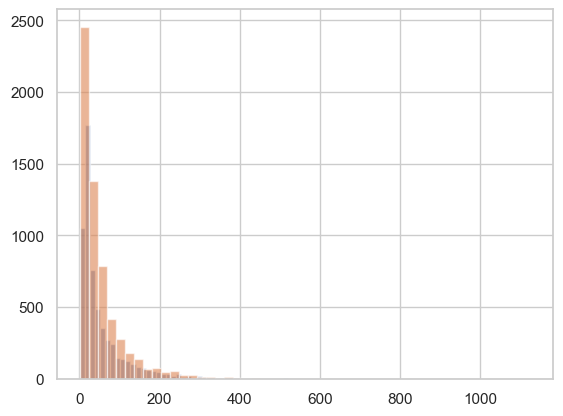

In [114]:
data[data['sentiment'] == 1]['text_len'].hist(alpha=0.6, bins=50)
data[data['sentiment'] == 0]['text_len'].hist(alpha=0.6, bins=50)


In [115]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', max_features=20)

pos_words = cv.fit_transform(
    data[data['sentiment'] == 1]['clean_text']
)
pd.Series(cv.get_feature_names_out())


0        author
1          book
2     character
3       enjoyed
4          good
5         great
6          know
7          life
8          like
9        little
10         love
11         make
12         read
13      reading
14       really
15       series
16        story
17         time
18         want
19          way
dtype: object

In [116]:
cv.fit_transform(data[data['sentiment'] == 0]['clean_text'])
pd.Series(cv.get_feature_names_out())


0        author
1          book
2     character
3         didnt
4          dont
5          good
6          know
7          like
8          love
9          make
10         plot
11         read
12      reading
13       really
14          sex
15        short
16        story
17        thing
18         time
19          way
dtype: object

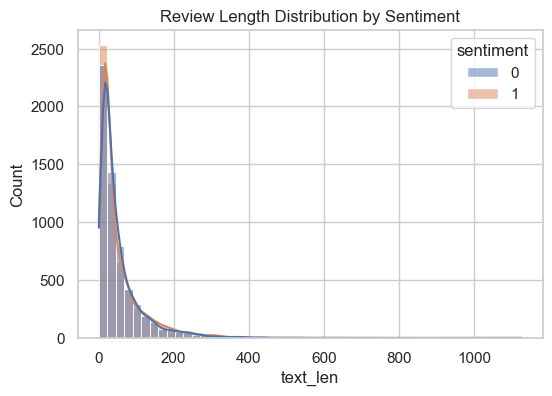

In [119]:

plt.figure(figsize=(6,4))
sns.histplot(
    data=data,
    x='text_len',
    hue='sentiment',
    bins=50,
    kde=True
)
plt.title("Review Length Distribution by Sentiment")
plt.show()


In [120]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(model, "../artifacts/sentiment_model.pkl")
joblib.dump(tfidf, "../artifacts/tfidf_vectorizer.pkl")


['../artifacts/tfidf_vectorizer.pkl']

In [121]:
loaded_model = joblib.load("../artifacts/sentiment_model.pkl")
loaded_vectorizer = joblib.load("../artifacts/tfidf_vectorizer.pkl")

sample = ["This book was amazing and very engaging"]
vec = loaded_vectorizer.transform(sample)
loaded_model.predict(vec)


array([1])